In [1]:
import numpy as np
from pandas import read_csv
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [3]:
df = read_csv("../../datasets/spambase.csv")
df.head(5)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [4]:
df.columns

Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',


In [7]:
x = df[['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',
       'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!',
       'char_freq_$', 'char_freq_#', 'capital_run_length_average',
       'capital_run_length_longest', 'capital_run_length_total']].values

y = df['spam'].values
print(x[0:5])
print(y[0:5])

[[0.000e+00 6.400e-01 6.400e-01 0.000e+00 3.200e-01 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 6.400e-01 0.000e+00 0.000e+00
  0.000e+00 3.200e-01 0.000e+00 1.290e+00 1.930e+00 0.000e+00 9.600e-01
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 7.780e-01 0.000e+00 0.000e+00 3.756e+00 6.100e+01
  2.780e+02]
 [2.100e-01 2.800e-01 5.000e-01 0.000e+00 1.400e-01 2.800e-01 2.100e-01
  7.000e-02 0.000e+00 9.400e-01 2.100e-01 7.900e-01 6.500e-01 2.100e-01
  1.400e-01 1.400e-01 7.000e-02 2.800e-01 3.470e+00 0.000e+00 1.590e+00
  0.000e+00 4.300e-01 4.300e-01 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 7.000e-02 0.000e+00 0.000e+00 0.000e+00

In [8]:
scaler = preprocessing.StandardScaler().fit(x)
x = scaler.fit_transform(x)
x[0:5]

array([[-3.42433707e-01,  3.30884903e-01,  7.12858774e-01,
        -4.68995838e-02,  1.15647106e-02, -3.50266176e-01,
        -2.91793886e-01, -2.62561558e-01, -3.23302359e-01,
        -3.71364386e-01, -2.96859527e-01,  1.14087333e-01,
        -3.12055206e-01, -1.74927167e-01, -1.90114405e-01,
         8.61714363e-02, -3.21135414e-01,  2.08120664e+00,
         1.50905374e-01, -1.67893113e-01,  1.25128398e-01,
        -1.18171509e-01, -2.90209203e-01, -2.12994388e-01,
        -3.28814669e-01, -2.99239934e-01, -2.27894812e-01,
        -2.31830156e-01, -1.66731450e-01, -2.25239518e-01,
        -1.60539307e-01, -1.43212021e-01, -1.74920257e-01,
        -1.45215148e-01, -1.98067390e-01, -2.42130222e-01,
        -3.23455613e-01, -5.98362369e-02, -1.80911344e-01,
        -1.85303849e-01, -1.20904684e-01, -1.72599962e-01,
        -2.05993114e-01, -1.27343320e-01, -2.97776209e-01,
        -1.97387481e-01, -7.13879045e-02, -1.11546231e-01,
        -1.58453362e-01, -5.14306549e-01, -1.55197675e-0

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=5)
print("training data: ", x_train.shape, y_train.shape)
print("testing data: ", x_test.shape, y_test.shape)

training data:  (3680, 57) (3680,)
testing data:  (921, 57) (921,)


In [10]:
Ks = 16
mean_acc = np.zeros((Ks-1))
fscores = np.zeros((Ks-1))

for n in range(1, Ks):
    neigh = KNeighborsClassifier(n_neighbors=n).fit(x_train, y_train)
    yhat = neigh.predict(x_test)

    print(f"k={n} acc={accuracy_score(y_test, yhat)} f1_s={f1_score(y_test, yhat, average='weighted')}")


k=1 acc=0.9305103148751357 f1_s=0.9304699260937754
k=2 acc=0.9153094462540716 f1_s=0.9141349471584561
k=3 acc=0.9163952225841476 f1_s=0.9163219752529834
k=4 acc=0.9174809989142236 f1_s=0.9167218416589549
k=5 acc=0.9185667752442996 f1_s=0.918397033857632
k=6 acc=0.9163952225841476 f1_s=0.9157777248875916
k=7 acc=0.9131378935939196 f1_s=0.9127634538048779
k=8 acc=0.9120521172638436 f1_s=0.9114025417648692
k=9 acc=0.9077090119435396 f1_s=0.9076281545000467
k=10 acc=0.9055374592833876 f1_s=0.9049716952582347
k=11 acc=0.9044516829533116 f1_s=0.9042229668654805
k=12 acc=0.9055374592833876 f1_s=0.9048397670807854
k=13 acc=0.9120521172638436 f1_s=0.911814137123923
k=14 acc=0.9098805646036916 f1_s=0.909150387035327
k=15 acc=0.9153094462540716 f1_s=0.9148882584442783


In [11]:
neigh = KNeighborsClassifier(n_neighbors=1).fit(x_train, y_train)
neigh

KNeighborsClassifier(n_neighbors=1)

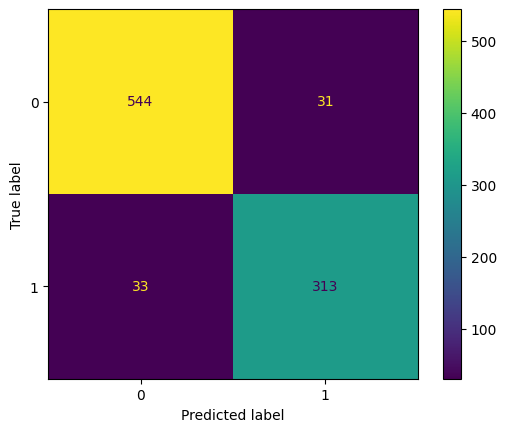

In [12]:
cm = confusion_matrix(y_test, neigh.predict(x_test))
disp = ConfusionMatrixDisplay(cm)
disp.plot()